In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [120]:
df = pd.read_csv(r"C:\internship project 1\project 2\Advertising Budget and Sales.csv")

print(df.head())

     TV   Radio   Newspaper    Sales 
0  230.1    37.8         69.2    22.1
1   44.5    39.3         45.1    10.4
2   17.2    45.9         69.3     9.3
3  151.5    41.3         58.5    18.5
4  180.8    10.8         58.4    12.9


In [121]:
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [122]:
df.isnull() .sum()

TV             0
Radio          0
Newspaper      0
Sales          0
dtype: int64

In [123]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [124]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool

In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   TV           200 non-null    float64
 1   Radio        200 non-null    float64
 2   Newspaper    200 non-null    float64
 3   Sales        200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [126]:
df.dtypes

TV             float64
Radio          float64
Newspaper      float64
Sales          float64
dtype: object

In [127]:
# Remove unnecessary column if exists
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

print(df.head())

     TV   Radio   Newspaper    Sales 
0  230.1    37.8         69.2    22.1
1   44.5    39.3         45.1    10.4
2   17.2    45.9         69.3     9.3
3  151.5    41.3         58.5    18.5
4  180.8    10.8         58.4    12.9


In [128]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


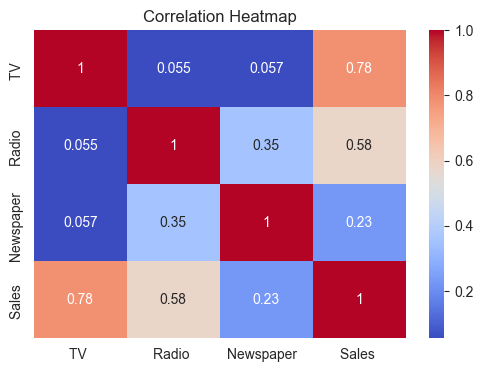

In [129]:
#Data Visualization

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [130]:
df.rename(columns={'TV ': 'TV'}, inplace=True)
df.rename(columns={'Radio ': 'Radio'}, inplace=True)
df.rename(columns={'Newspaper ': 'Newspaper'}, inplace=True)
df.rename(columns={'Sales ': 'Sales'}, inplace=True)

In [131]:
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


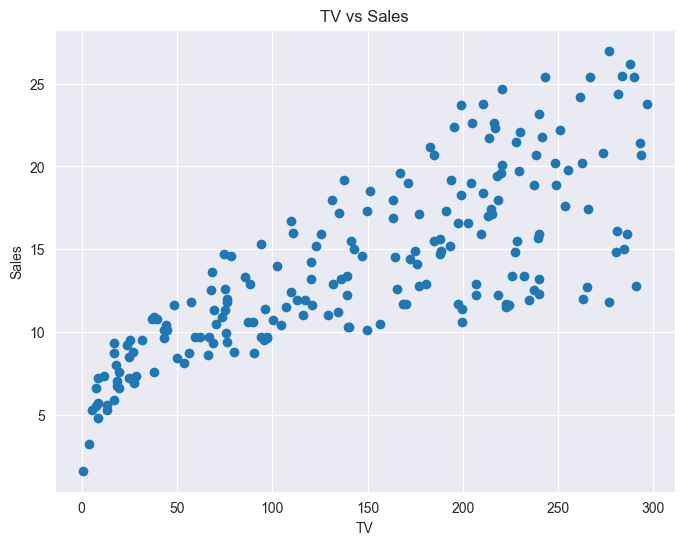

In [132]:
#TV&Sales
plt.figure(figsize=(8,6))
plt.scatter(df['TV'], df['Sales'])
plt.xlabel("TV")
plt.ylabel("Sales")
plt.title("TV vs Sales")
plt.show()

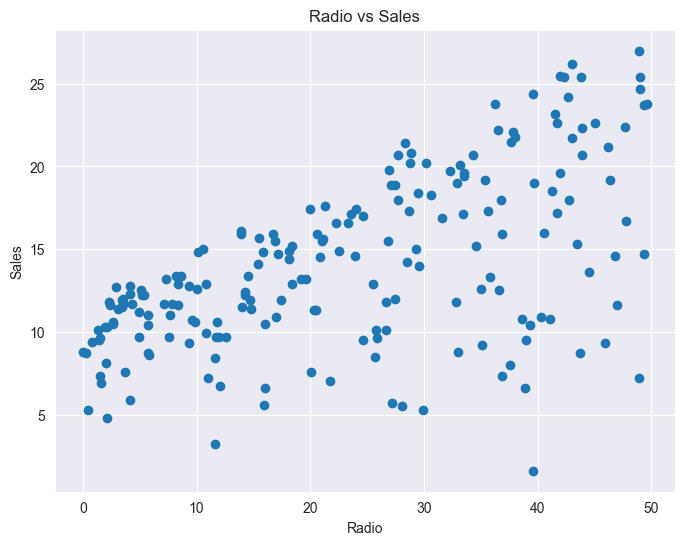

In [133]:
plt.figure(figsize=(8,6))
plt.scatter(df['Radio'], df['Sales'])
plt.xlabel("Radio")
plt.ylabel("Sales")
plt.title("Radio vs Sales")
plt.show()

In [134]:
print(df.columns)

Index(['TV', 'Radio', 'Newspaper  ', 'Sales'], dtype='str')


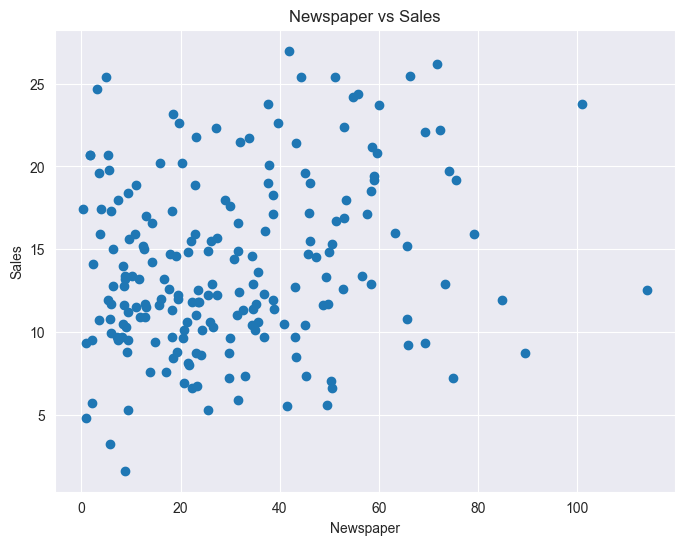

In [135]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['Newspaper  '], df['Sales'])
plt.xlabel("Newspaper")
plt.ylabel("Sales")
plt.title("Newspaper vs Sales")
plt.show()

In [195]:
#Feature selection
x= df[['TV','Radio']]  
y= df['Sales']   

In [175]:
#Split dataset
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [176]:
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


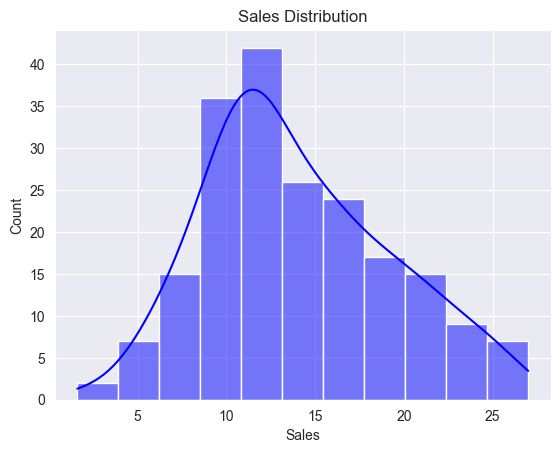

In [177]:
#Distribution salesplott
sns.set_style("darkgrid")

sns.histplot(df['Sales'], kde=True, color='blue')

plt.title("Sales Distribution")

plt.show()

In [178]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


In [179]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [180]:
y_pred = model.predict(X_test_poly)


In [181]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("R2 Score:", r2)
print("Mean Squared Error:", mse)


R2 Score: 0.9884627879931589
Mean Squared Error: 0.36415587279155304


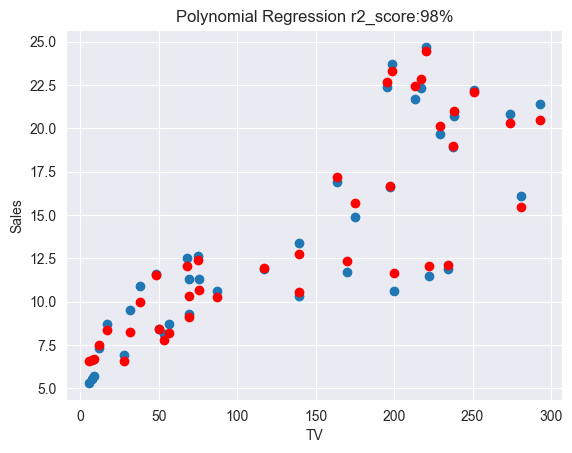

In [186]:
plt.scatter(X_test['TV'], y_test)

plt.scatter(X_test['TV'], model.predict(X_test_poly), color='red')

plt.xlabel("TV")

plt.ylabel("Sales")

plt.title("Polynomial Regression r2_score:98%")

plt.show()

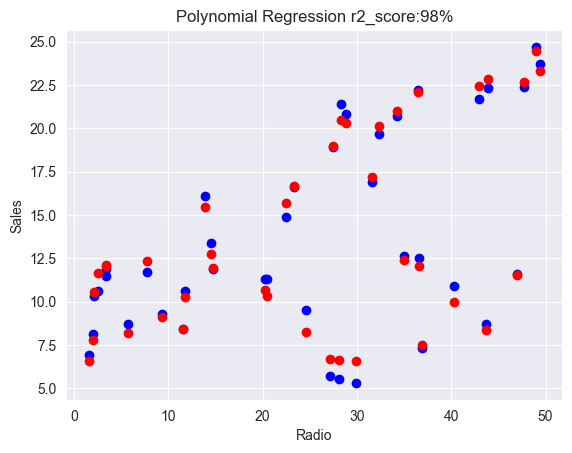

In [193]:
plt.scatter(X_test['Radio'], y_test,color='blue')
plt.scatter(X_test['Radio'], model.predict(X_test_poly), color='red')
plt.xlabel("Radio")
plt.ylabel("Sales")
plt.title("Polynomial Regression r2_score:98%")
plt.show()

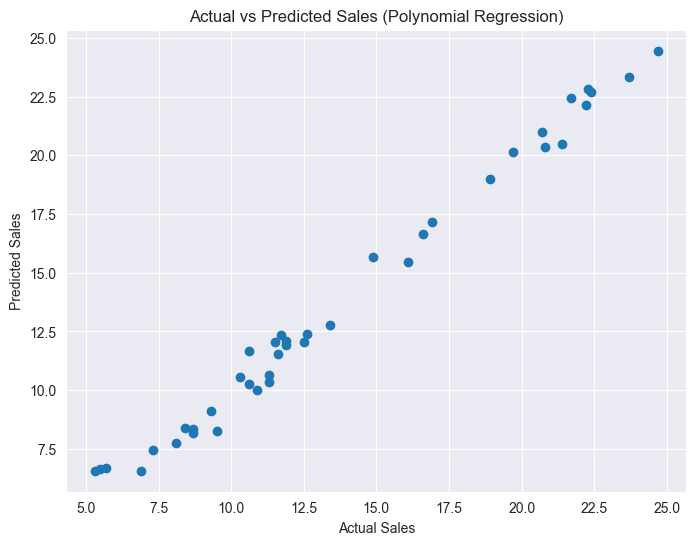

In [ ]:
#Actual VS Predicted Sales
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Polynomial Regression)")
plt.show()
